# UdaciMed | Notebook 2: Architecture Optimization

Welcome back to UdaciMed's optimization pipeline! In this notebook, you will implement hardware-aware architectural modifications to achieve our critical memory reduction goals.

### Recap: **Optimization challenge**

From [Notebook 1](01_baseline_analysis.ipynb), we identified that our ResNet-18 baseline model faces **memory, computation, speed, and throughput challenges**:

- **Target FLOP reduction**: >80% _(to achieve <0.4 GFLOPs per sample)_
- **Target memory usage**: <100MB 
- **Target throughput**: >2,000 samples/sec 
- **Target latency**: <3ms

Note on memory: the <100MB target can refer to **model weights + buffers** or **peak inference memory**. We'll report both below; peak memory depends on batch size (we profile with batch size 1 for deployment-like latency). At FP32 that's ~25M parameters; at FP16 ~50M; at INT8 ~100M for weights.

while keeping **model sensitivity** >98%.

You have outlined an optimization strategy as part of your baseline model analysis, it is now time to develop the architectural optimizations.

### **Architecture optimization strategy**

You will implement and evaluate at least **3 architecture optimization techniques** out of the ones previously analyzed, as listed below:

1. Interpolation Removal
2. Depthwise Separable Convolution
3. Grouped Convolutions
4. Inverted Residual Blocks
5. Low-Rank Factorization
6. Channel Optimization
7. Parameter Sharing

Test all implemented techniques separately, and collect results. Then, decide the final optimization strategy (not all need to be enabled!) for the next phase.

---

Through this notebook, you will:
- **Implement >=3 optimization techniques** with modular toggles
- **Compare performance impacts** across memory, latency, FLOPs, and throughput
- **Validate clinical safety** by monitoring sensitivity metrics
- **Create an optimized model** with the most efficient architectural optimization settings

**Let's transform our baseline into a production-ready, memory-efficient diagnostic model!**

## Step 1: Setup and load baseline results

First, let's set up the environment and load our baseline model with analysis from Notebook 1.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
import random
import copy
import matplotlib.pyplot as plt
from pprint import pprint
from torchsummary import summary
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds,
    evaluate_model
)
from utils.profiling import (
    PerformanceProfiler,
    measure_time
)
from utils.visualization import (
    plot_batch_size_comparison,
    plot_performance_profile,
    plot_operation_breakdown
)
from utils.architecture_optimization import (
    apply_interpolation_removal_optimization,
    apply_depthwise_separable_optimization,
    apply_grouped_convolution_optimization,
    apply_inverted_residual_optimization,
    apply_lowrank_factorization,
    apply_channel_optimization,
    apply_parameter_sharing,
    create_optimized_model
)

# Set the device for pytorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: CUDA not available - optimization profiling will be limited")

print("Architecture optimization environment ready!")

Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
GPU Memory: 12.0 GB
Architecture optimization environment ready!


In [3]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


> **Why deterministic mode matters**
>
> Small variations in random initialization can make it difficult to assess the true impact of optimization techniques. Deterministic mode ensures that performance differences reflect architectural changes, not random variation.

In [4]:
# Updated targets based on baseline analysis findings
OPTIMIZATION_TARGETS = {
    'memory_mb': 100,                   # MB 
    'throughput_samples_sec': 2000,     # samples/sec
    'latency_ms': 3,                    # ms 
    'sensitivity_percent': 98,          # %
    'flop_reduction_percent': 80        # % 
}

print("Optimization targets for production deployment:")
for metric, target in OPTIMIZATION_TARGETS.items():
    print(f"   {metric.replace('_', ' ').title()}: {target}")

Optimization targets for production deployment:
   Memory Mb: 100
   Throughput Samples Sec: 2000
   Latency Ms: 3
   Sensitivity Percent: 98
   Flop Reduction Percent: 80


In [5]:
# Load baseline results from Notebook 1
try:
    with open('../results/baseline_results.pkl', 'rb') as f:
        baseline_results = pickle.load(f)
    
    print("Loaded baseline results from Notebook 1:")
    print(f"   Model: {baseline_results['model_name']}")
    print(f"   Parameters: {baseline_results['total_parameters']:,}")
    print(f"   Model Size: {baseline_results['model_size_mb']:.1f} MB")
    print(f"   Memory Usage: {baseline_results['memory']['peak_memory_mb']:.1f} MB")
    print(f"   Inference Time: {baseline_results['timing']['single_sample_ms']:.2f} ms")
    print(f"   Throughput: {baseline_results['timing']['batch_throughput_samples_per_sec']:.0f} samples/sec")
    print(f"   Clinical Sensitivity: {baseline_results['eval_results'][0.7]['recall']:.1%}")
    
except FileNotFoundError:
    print("ERROR: Baseline results not found. Please run Notebook 1 first.")
    raise

Loaded baseline results from Notebook 1:
   Model: ResNet-18 Baseline
   Parameters: 11,177,538
   Model Size: 42.6 MB
   Memory Usage: 318.2 MB
   Inference Time: 1.82 ms
   Throughput: 3816 samples/sec
   Clinical Sensitivity: 99.0%


In [6]:
# Recreate baseline model and load the trained weights
baseline_config = baseline_results['config']

# Set input resolution (use baseline size for best accuracy)
# To prioritize peak-memory reductions, try 28 or 32 (with a resize transform).
experiment_image_size = baseline_config['image_size']

baseline_model = create_baseline_model(
    num_classes=baseline_config['num_classes'], 
    input_size=experiment_image_size, 
    pretrained=False
)

try:
    baseline_model.load_state_dict(torch.load('../results/best_baseline_model.pth', map_location=device))
    baseline_model = baseline_model.to(device)
    baseline_model.eval()
    print("Loaded trained baseline model successfully")
except FileNotFoundError:
    print("WARNING: Trained model weights not found. Using randomly initialized model.")
    baseline_model = baseline_model.to(device)

Loaded trained baseline model successfully


In [7]:
# Load test dataset for evaluation
test_loader = load_pneumoniamnist(
    split="test", 
    download=True, 
    size=experiment_image_size, 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.15 if baseline_config['subset_size'] is not None else None
)

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(test_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"Test data loaded: {sample_images.shape} batch for profiling")
print(f"   Batch memory footprint: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")
print(f"   Class distribution: {sample_labels.sum().item()}/{len(sample_labels)} positive cases")

Using downloaded and verified file: /home/lence/.medmnist/pneumoniamnist_64.npz
Test data loaded: torch.Size([32, 3, 64, 64]) batch for profiling
   Batch memory footprint: 1.5 MB
   Class distribution: 23/32 positive cases


## Step 2: Configure optimization strategy

Define which optimizations to apply. 

Each technique can be independently enabled/disabled, allowing you to understand individual contributions and find the optimal combination for your use case.

In [8]:
# Configure your optimization strategy by setting each technique to True/False
# Start with one technique at a time for analysis, then combine based on results

OPTIMIZATION_CONFIG = {
    # Enable/disable optimizations
    'interpolation_removal': True,
    'depthwise_separable': True,
    'channel_optimization': True,
    'grouped_conv': False,
    'inverted_residuals': False,
    'lowrank_factorization': False,
    'parameter_sharing': False,

    # Optional per-technique parameters (passed into create_optimized_model)
    'interpolation_removal_params': {'native_size': experiment_image_size},
    'depthwise_separable_params': {'min_channels': 32, 'preserve_residuals': True},
    'channel_optimization_params': {'enable_channels_last': True, 'enable_inplace_relu': True},
    'grouped_conv_params': {'groups': 2, 'min_channels': 32},
    'inverted_residuals_params': {'expand_ratio': 6},
    'lowrank_factorization_params': {'min_params': 10_000, 'rank_ratio': 0.25},
    'parameter_sharing_params': {},

    # Execution parameters for training and inference
    'memory_format': torch.channels_last,
    'use_amp': torch.cuda.is_available()
}

print("Optimization configuration:")
for technique, enabled in OPTIMIZATION_CONFIG.items():
    if isinstance(enabled, bool):
        status = "ENABLED" if enabled else "DISABLED"
        print(f"   {technique.replace('_', ' ').title()}: {status}")

Optimization configuration:
   Interpolation Removal: ENABLED
   Depthwise Separable: ENABLED
   Channel Optimization: ENABLED
   Grouped Conv: DISABLED
   Inverted Residuals: DISABLED
   Lowrank Factorization: DISABLED
   Parameter Sharing: DISABLED
   Use Amp: ENABLED


> **Tips for optimization strategy**: 
> 
> 1. Start with one technique at a time to understand individual contributions. 
> 2. Experiment with different optimization parameters by updating the parameters set in the optimization function calls in `create_optimized_model()` (less refactoring), or update `create_optimized_model()` to take parameters from _`OPTIMIZATION_CONFIG`_ and set them directly in the config (more seamless experimentation).

## Step 3: Apply architectural optimizations

Now let's create the optimized model by applying your selected techniques.

The optimization methods are implemented in `utils/architecture_optimization.py`, and this section applies them in a reproducible order.

In [9]:
print("Creating optimized model with selected techniques...")

# Apply optimizations using the architecture optimization utility in the correct order (some optimizations build on others)
optimized_model = create_optimized_model(baseline_model, OPTIMIZATION_CONFIG)
optimized_model = optimized_model.to(device)

print("\nOptimized model created successfully!")
print(f"   Device: {next(optimized_model.parameters()).device}")

Creating optimized model with selected techniques...
Starting clinical model optimization pipeline...
   Applying interpolation removal optimization...
Applying native resolution optimization (64x64)...
   Updated target_size to 64
INTERPOLATION REMOVAL completed.
   Applying depthwise separable optimization...
Applying depthwise separable convolution optimization...
DEPTHWISE SEPARABLE completed: Successfully applied to layers with 16 replacements
   Applying channel optimization optimization...
Applying channel-level hardware optimizations...
   Converted model to channels_last memory format
   Enabled in-place for 9 ReLU/ReLU6 layers
CHANNEL OPTIMIZATION completed
Applied optimizations in order: interpolation_removal → depthwise_separable → channel_optimization

Optimized model created successfully!
   Device: cuda:0


In [10]:
# Ensure sample inputs use the configured memory format for profiling
if OPTIMIZATION_CONFIG.get('memory_format') == torch.channels_last:
    sample_images = sample_images.contiguous(memory_format=torch.channels_last)
    print("Converted sample inputs to channels_last for profiling")

Converted sample inputs to channels_last for profiling


In [11]:
# Review new model architecture
summary(optimized_model, input_size=(3, experiment_image_size, experiment_image_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]             576
            Conv2d-6           [-1, 64, 16, 16]           4,096
       BatchNorm2d-7           [-1, 64, 16, 16]             128
              ReLU-8           [-1, 64, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]             576
           Conv2d-10           [-1, 64, 16, 16]           4,096
      BatchNorm2d-11           [-1, 64, 16, 16]             128
             ReLU-12           [-1, 64, 16, 16]               0
       BasicBlock-13           [-1, 64, 16, 16]               0
           Conv2d-14           [-1, 64,

> **How have the optimizations changed the expected model size in MB?**
> 
> Optimizations can either increase or decrease different memory components for the model. Use the above summary as a sanity check for your optimizations' implementations.

In [12]:
# Analyze the new memory footprint
def count_unique_parameters(model):
    """Count actual unique parameter tensors (shared params counted once)"""
    unique_params = {}
    
    for name, param in model.named_parameters():
        param_id = id(param)
        if param_id not in unique_params:
            unique_params[param_id] = {
                'tensor': param,
                'shape': param.shape,
                'elements': param.numel(),
                'first_seen': name,
                'shared_with': []
            }
        else:
            unique_params[param_id]['shared_with'].append(name)
    
    total_unique_elements = sum(info['elements'] for info in unique_params.values())
    
    return total_unique_elements, len(unique_params), unique_params

def estimate_model_size_mb(model, unique_params):
    """Estimate model weights + buffers size in MB"""
    unique_param_bytes = sum(
        info['tensor'].numel() * info['tensor'].element_size()
        for info in unique_params.values()
    )
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    return (unique_param_bytes + buffer_bytes) / (1024 ** 2)

baseline_unique, baseline_objects, baseline_params_details = count_unique_parameters(baseline_model)
optimized_unique, optimized_objects, optimized_params_details = count_unique_parameters(optimized_model)

baseline_state_size = sum(p.numel() for p in baseline_model.parameters())
optimized_state_size = sum(p.numel() for p in optimized_model.parameters())

baseline_model_size_mb = estimate_model_size_mb(baseline_model, baseline_params_details)
optimized_model_size_mb = estimate_model_size_mb(optimized_model, optimized_params_details)

print(f"Baseline model:")
print(f"   State dict size: {baseline_state_size:,} elements")
print(f"   Unique parameters: {baseline_unique:,} elements")
print(f"   Model size (params+buffers): {baseline_model_size_mb:.1f} MB")

print(f"Optimized model:")
print(f"   State dict size: {optimized_state_size:,} elements")
print(f"   Unique parameters: {optimized_unique:,} elements")
print(f"   Model size (params+buffers): {optimized_model_size_mb:.1f} MB")

reduction = ((baseline_state_size - optimized_state_size) / baseline_state_size * 100)
print(f"Total parameter reduction: {reduction:.1f}%")

n_shared_params = sum([len(param_details['shared_with']) for param_id, param_details in optimized_params_details.items()])
print(f"# Shared parameters: {n_shared_params}")

print(f"Meets <{OPTIMIZATION_TARGETS['memory_mb']}MB target: {optimized_model_size_mb < OPTIMIZATION_TARGETS['memory_mb']}")

Baseline model:
   State dict size: 11,177,538 elements
   Unique parameters: 11,177,538 elements
   Model size (params+buffers): 42.7 MB
Optimized model:
   State dict size: 1,443,202 elements
   Unique parameters: 1,443,202 elements
   Model size (params+buffers): 5.5 MB
Total parameter reduction: 87.1%
# Shared parameters: 0
Meets <100MB target: True


> **Do you see the expected parameter reduction?**
> 
> The analysis above showcases both parameter reduction and parameter sharing (if applied). Optimizing model parameters directly contributes to memory savings, but remember: activation memory during inference often dominates, especially with larger input sizes!

## Step 4: Initialize optimized model via transfer learning

While we have changed the architecture, we can still transfer knowledge from the trained baseline model to our optimized architecture for any matching layers.

Preserving learned features where possible reduces retraining time and maintains clinical performance.

In [13]:
# Transfer compatible weights from baseline to optimized model
# This preserves learned features where possible, reducing retraining time

def transfer_compatible_weights(source_model, target_model):
    """
    Transfer weights from source model to target model where layer shapes match.
    This preserves learned representations in unmodified layers.
    """
    source_dict = dict(source_model.named_parameters())
    target_dict = dict(target_model.named_parameters())
    
    transferred_layers = []
    skipped_layers = []

    # Iterate through layers and define if they can be transferred or need skipping
    for name, target_param in target_dict.items():
        if name in source_dict:
            source_param = source_dict[name]
            if source_param.shape == target_param.shape:
                with torch.no_grad():
                    target_param.copy_(source_param)
                transferred_layers.append(name)
            else:
                skipped_layers.append(name)
        else:
            skipped_layers.append(name)
    
    return transferred_layers, skipped_layers

print("Transferring compatible weights from baseline to optimized model...")
transferred, skipped = transfer_compatible_weights(baseline_model, optimized_model)

print(f"\nTransferred {len(transferred)} compatible layers")
print(f"Skipped {len(skipped)} modified/new layers")

Transferring compatible weights from baseline to optimized model...

Transferred 46 compatible layers
Skipped 32 modified/new layers


## Step 5: Train/Fine-tune the optimized model

The optimized model needs training to learn the weights of new layers defined by the architectural changes.

If the number of new layers is low, keep in mind that lower learning rates can help preserve transferred knowledge while adapting to architectural changes for faster convergence.

In [14]:
# Load training data for fine-tuning the optimized model
# We need both training and validation data to fine-tune the model

train_loader = load_pneumoniamnist(
    split="train", 
    download=True, 
    size=experiment_image_size, 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.7 if baseline_config['subset_size'] is not None else None
)

val_loader = load_pneumoniamnist(
    split="val", 
    download=True, 
    size=experiment_image_size, 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.15 if baseline_config['subset_size'] is not None else None
)

print(f"Training data loaded:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Image size: {experiment_image_size}x{experiment_image_size}")

Using downloaded and verified file: /home/lence/.medmnist/pneumoniamnist_64.npz
Using downloaded and verified file: /home/lence/.medmnist/pneumoniamnist_64.npz
Training data loaded:
   Training batches: 148
   Validation batches: 17
   Image size: 64x64


In [15]:
# Configure training parameters
# Update the training regime in train_baseline_model() if desired

FINE_TUNING_CONFIG = {
    'num_epochs': 5,
    'learning_rate': 0.0001,
    'lr_step_size': 3,
    'weight_decay': 1e-4,
    'patience': 3,
    'memory_format': OPTIMIZATION_CONFIG['memory_format']
}

print("Fine-tuning configuration:")
for key, value in FINE_TUNING_CONFIG.items():
    print(f"   {key}: {value}")

Fine-tuning configuration:
   num_epochs: 5
   learning_rate: 0.0001
   lr_step_size: 3
   weight_decay: 0.0001
   patience: 3
   memory_format: torch.channels_last


Fine-tuning optimized model...
Starting baseline model training for pneumonia detection...
   Config: 5 epochs, lr=0.0001, wd=0.0001


   Epoch  1: Train Acc  92.7% | Val Acc  95.8% | Train Loss 0.1885 | Val Loss 0.1109 | LR 0.000100
      New best model saved (Val Acc: 95.8%)


   Epoch  2: Train Acc  97.7% | Val Acc  96.4% | Train Loss 0.0642 | Val Loss 0.1091 | LR 0.000100
      New best model saved (Val Acc: 96.4%)


   Epoch  3: Train Acc  98.6% | Val Acc  96.9% | Train Loss 0.0366 | Val Loss 0.1151 | LR 0.000100
      New best model saved (Val Acc: 96.9%)


   Epoch  4: Train Acc  99.7% | Val Acc  96.9% | Train Loss 0.0116 | Val Loss 0.1069 | LR 0.000010


   Epoch  5: Train Acc  99.9% | Val Acc  96.9% | Train Loss 0.0067 | Val Loss 0.1122 | LR 0.000010
Training completed! Best validation accuracy: 96.95%


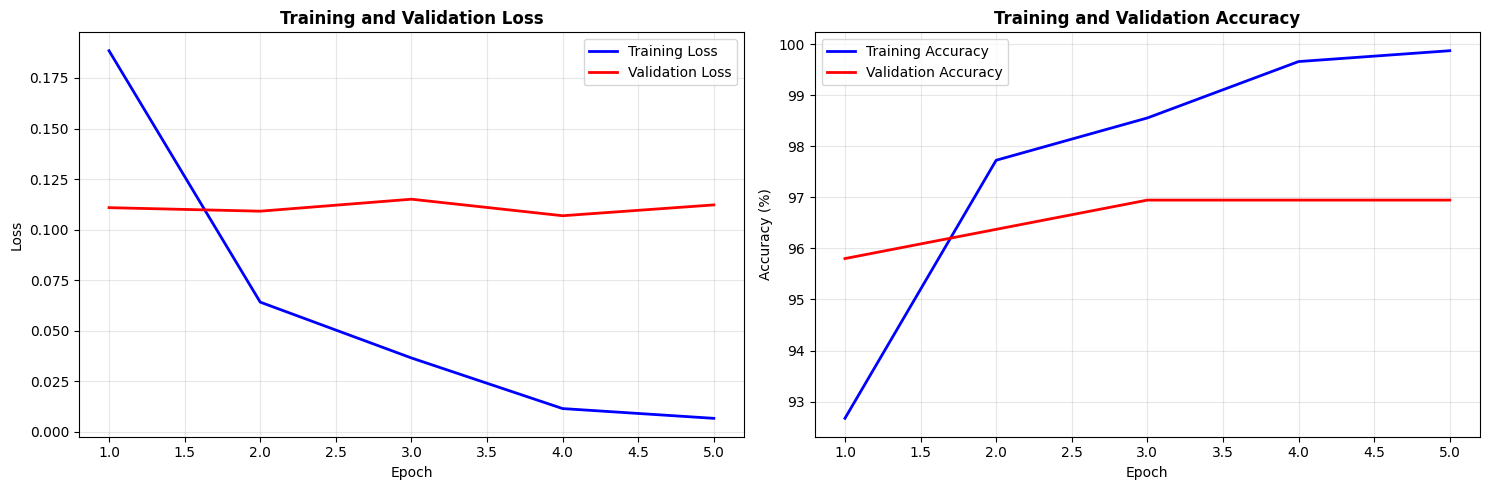


Training Summary:
   Best Validation Accuracy: 96.9%
   Total Epochs: 5
   Final Training Accuracy: 99.9%
   Final Validation Accuracy: 96.9%


In [16]:
# Train/Fine-tune the optimized model
print("Fine-tuning optimized model...")
optimized_model, fine_tuning_history = train_baseline_model(
    optimized_model, train_loader, val_loader, device, FINE_TUNING_CONFIG, save_path="../results/optimized_model.pth",
)

# Plot fine-tuning progress
plot_training_history(fine_tuning_history)

> **_Indicators of training success_**:
> 
> - **Validation accuracy** should recover to within 1-2% of baseline (target: >98%)
> - **Training should converge quickly** (2-5 epochs), especially with transferred weights
> - **Loss curves should be smooth** without significant overfitting
> 
> If training struggles, consider: reducing learning rate, increasing epochs, or simplifying optimizations.

## Step 6: Evaluate clinical performance

Critical step: validate that optimizations maintain clinical safety standards.

In [17]:
# Evaluate clinical performance of the optimized model
print("Evaluating clinical performance of optimized model...")

# Evaluate optimized model across thresholds on validation set (avoid test leakage)
thresholds = [round(t, 2) for t in np.linspace(0.2, 0.8, 13)]
optimized_val_results = evaluate_with_multiple_thresholds(optimized_model, val_loader, device, thresholds)

# Select the threshold that meets sensitivity >=98% and maximizes specificity (tie-break on accuracy)
def select_threshold(results, min_recall=0.98):
    best_thr = None
    best_score = (-1.0, -1.0)

    for thr, metrics in results.items():
        if metrics.get('recall', 0) < min_recall:
            continue
        if 'confusion_matrix' in metrics:
            tn, fp, fn, tp = metrics['confusion_matrix'].ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            specificity = 0.0
        score = (specificity, metrics.get('accuracy', 0))
        if score > best_score:
            best_score = score
            best_thr = thr

    if best_thr is None:
        # Fallback: maximize recall, then accuracy if no threshold hits the recall target
        for thr, metrics in results.items():
            score = (metrics.get('recall', 0), metrics.get('accuracy', 0))
            if score > best_score:
                best_score = score
                best_thr = thr

    return best_thr

optimized_classification_threshold = select_threshold(optimized_val_results, min_recall=0.98)
print(f"Selected optimized threshold (val): {optimized_classification_threshold:.2f}")

# Evaluate on test set using the selected threshold
optimized_metrics = evaluate_model(optimized_model, test_loader, device, threshold=optimized_classification_threshold)

Evaluating clinical performance of optimized model...

Evaluating with threshold 0.2:
Clinical Evaluation Results (threshold: 0.200):
   Accuracy:  97.1%
   Precision: 97.5% (PPV - Positive Predictive Value)
   Recall:    98.7% (Sensitivity)
   F1 Score:  98.1%
   AUC-ROC:   0.994

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     125
   False Positives (Normal misclassified):            10
   False Negatives (Pneumonia missed):                 5
   True Positives (Pneumonia correctly detected):   384

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.7% (detects 98.7% of pneumonia cases)
   Specificity (True Negative Rate):     92.6% (correctly identifies 92.6% of normal cases)
   PPV (Positive Predictive Value):      97.5% (when model predicts pneumonia, it's correct 97.5% of time)
   NPV (Negative Predictive Value):      96.2% (when model predicts normal, it's correct 96.2% of time)

Clinical Significance:
   False Negativ

In [18]:
# Compare optimized model performance against baseline

baseline_val_results = evaluate_with_multiple_thresholds(baseline_model, val_loader, device, thresholds)
baseline_classification_thr = select_threshold(baseline_val_results, min_recall=0.98)
print(f"Selected baseline threshold (val): {baseline_classification_thr:.2f}")

baseline_metrics = evaluate_model(baseline_model, test_loader, device, threshold=baseline_classification_thr)

print("BASELINE vs OPTIMIZED PERFORMANCE COMPARISON:")
print(f"\n   Sensitivity (Recall):")
print(f"     Baseline:  {baseline_metrics['recall']:.1%}")
print(f"     Optimized: {optimized_metrics['recall']:.1%}")
sensitivity_change = (optimized_metrics['recall'] - baseline_metrics['recall']) * 100
print(f"     Change:    {sensitivity_change:+.1f} percentage points")

print(f"\n   Overall Accuracy:")
print(f"     Baseline:  {baseline_metrics['accuracy']:.1%}")
print(f"     Optimized: {optimized_metrics['accuracy']:.1%}")
accuracy_change = (optimized_metrics['accuracy'] - baseline_metrics['accuracy']) * 100
print(f"     Change:    {accuracy_change:+.1f} percentage points")

print(f"\n   AUC-ROC:")
print(f"     Baseline:  {baseline_metrics['auc']:.3f}")
print(f"     Optimized: {optimized_metrics['auc']:.3f}")
auc_change = optimized_metrics['auc'] - baseline_metrics['auc']
print(f"     Change:    {auc_change:+.3f}")

# Clinical safety assessment
print(f"\nCLINICAL SAFETY ASSESSMENT:")
optimized_sensitivity = optimized_metrics['recall']
if optimized_sensitivity >= 0.98:
    print(f"   SAFE: Sensitivity {optimized_sensitivity:.1%} meets clinical requirement (>98%)")
else:
    print(f"   WARNING: Sensitivity {optimized_sensitivity:.1%} below clinical requirement (>98%)")
    print(f"   RECOMMENDATION: Reduce optimization aggressiveness or retrain with sensitivity focus")

if abs(accuracy_change) <= 2.0:
    print(f"   ACCEPTABLE: Accuracy change {accuracy_change:+.1f}% within tolerance (±2%)")
else:
    print(f"   CAUTION: Accuracy change {accuracy_change:+.1f}% exceeds tolerance (±2%)")


Evaluating with threshold 0.2:
Clinical Evaluation Results (threshold: 0.200):
   Accuracy:  98.1%
   Precision: 98.2% (PPV - Positive Predictive Value)
   Recall:    99.2% (Sensitivity)
   F1 Score:  98.7%
   AUC-ROC:   0.997

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     128
   False Positives (Normal misclassified):             7
   False Negatives (Pneumonia missed):                 3
   True Positives (Pneumonia correctly detected):   386

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     99.2% (detects 99.2% of pneumonia cases)
   Specificity (True Negative Rate):     94.8% (correctly identifies 94.8% of normal cases)
   PPV (Positive Predictive Value):      98.2% (when model predicts pneumonia, it's correct 98.2% of time)
   NPV (Negative Predictive Value):      97.7% (when model predicts normal, it's correct 97.7% of time)

Clinical Significance:
   False Negative Rate: 0.8% (missed pneumonia cases - critical for pa

## Step 7: Profile optimized model performance

Now let's measure the performance improvements from our optimizations.

Quantifying improvements validates that optimizations achieve their intended benefits and helps prioritize techniques for future projects.

In [19]:
# Profile the optimized model's inference performance
print("Profiling optimized model performance...")

# Initialize profiler
profiler = PerformanceProfiler(device=str(device), use_amp=OPTIMIZATION_CONFIG["use_amp"])

# Profile timing
optimized_timing = profiler.profile_inference_time(
    model=optimized_model,
    input_tensor=sample_images,
    num_runs=100,
    warmup_runs=10
)

print(f"\nTIMING RESULTS:")
print(f"   Single Sample Latency: {optimized_timing['single_sample_ms']:.2f} ms")
print(f"   Batch Throughput: {optimized_timing['batch_throughput_samples_per_sec']:.0f} samples/sec")
print(f"   Mean Inference Time: {optimized_timing['mean_ms']:.2f} ms")
print(f"   95th Percentile: {optimized_timing['p95_ms']:.2f} ms")

Profiling optimized model performance...

TIMING RESULTS:
   Single Sample Latency: 2.42 ms
   Batch Throughput: 13289 samples/sec
   Mean Inference Time: 2.42 ms
   95th Percentile: 2.86 ms


In [20]:
# Profile FLOPs of the optimized model
optimized_flops = profiler.profile_flops(
    model=optimized_model, 
    input_tensor=sample_images
)

if 'error' not in optimized_flops:
    print(f"\nFLOPs Results:")
    print(f"   Total: {optimized_flops['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {optimized_flops['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in optimized_flops and optimized_flops['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(optimized_flops['module_percentage'].items())[:5]:
            gflops = optimized_flops['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")
else:
    print(f"WARNING: FLOPs calculation failed: {optimized_flops['error']}")
    optimized_flops = {}

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 0.89 GFLOPs
   Per Sample: 0.03 GFLOPs

   Top Operations (by FLOPs):
     conv: 98.5% (0.88 GFLOPs)
     batch_norm: 1.5% (0.01 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [21]:
# Profile memory usage of the optimized model
memory_profile_batch_size = 1
memory_profile_images = sample_images[:memory_profile_batch_size]

if OPTIMIZATION_CONFIG.get('memory_format') == torch.channels_last:
    memory_profile_images = memory_profile_images.contiguous(memory_format=torch.channels_last)

print(f"Profiling memory with batch size: {memory_profile_images.size(0)}")

# Profile models one at a time to avoid double-counting GPU allocations
if torch.cuda.is_available():
    optimized_model = optimized_model.to("cpu")
    torch.cuda.empty_cache()

baseline_model = baseline_model.to(device)
baseline_memory_profiled = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=memory_profile_images
)

if torch.cuda.is_available():
    baseline_model = baseline_model.to("cpu")
    torch.cuda.empty_cache()

optimized_model = optimized_model.to(device)
optimized_memory = profiler.profile_memory_usage(
    model=optimized_model,
    input_tensor=memory_profile_images
)

if 'error' not in optimized_memory:
    print(f"\nMEMORY RESULTS (optimized):")
    print(f"   Peak Memory: {optimized_memory['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {optimized_memory['memory_increase_mb']:.1f} MB")
    
    if 'component_breakdown' in optimized_memory:
        components = optimized_memory['component_breakdown']
        print(f"\n   Memory Component Breakdown:")
        for component, usage in components.items():
            print(f"     {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {optimized_memory['error']}")
    optimized_memory = {}

if 'error' in baseline_memory_profiled:
    print(f"WARNING: Baseline memory profiling error: {baseline_memory_profiled['error']}")
    baseline_memory_profiled = {}

Profiling memory with batch size: 1

MEMORY RESULTS (optimized):
   Peak Memory: 157.9 MB
   Memory Increase: 128.8 MB

   Memory Component Breakdown:
     Model Parameters Mb: 5.5 MB
     Input Tensor Mb: 0.0 MB
     Output Tensor Mb: 0.0 MB
     Activations Mb: 128.7 MB


In [22]:
# Compare performance improvements against baseline to validate progress toward optimization targets

# Get baseline performance metrics
baseline_timing = baseline_results['timing']
baseline_memory = baseline_results['memory']
baseline_flops = baseline_results['flops']

print("PERFORMANCE IMPROVEMENT ANALYSIS:")

# Timing improvements
latency_improvement = baseline_timing['single_sample_ms'] / optimized_timing['single_sample_ms']
throughput_improvement = optimized_timing['batch_throughput_samples_per_sec'] / baseline_timing['batch_throughput_samples_per_sec']

print(f"\nSpeed Improvements:")
print(f"   Latency Speedup: {latency_improvement:.2f}x ({baseline_timing['single_sample_ms']:.2f}ms → {optimized_timing['single_sample_ms']:.2f}ms)")

# Memory improvements
memory_reduction = None
baseline_memory_compare = baseline_memory
memory_profile_note = ""

if 'baseline_memory_profiled' in globals() and baseline_memory_profiled and 'error' not in baseline_memory_profiled:
    baseline_memory_compare = baseline_memory_profiled
if 'memory_profile_images' in globals():
    memory_profile_note = f" (batch size {memory_profile_images.size(0)})"

if 'error' not in optimized_memory and baseline_memory_compare and 'error' not in baseline_memory_compare:
    memory_reduction = (baseline_memory_compare['peak_memory_mb'] - optimized_memory['peak_memory_mb']) / baseline_memory_compare['peak_memory_mb'] * 100
    print(f"\n Memory Improvements{memory_profile_note}:")
    print(f"   Memory Reduction: {memory_reduction:.1f}% ({baseline_memory_compare['peak_memory_mb']:.1f}MB → {optimized_memory['peak_memory_mb']:.1f}MB)")

    if 'component_breakdown' in optimized_memory:
        optimized_params_mb = optimized_memory['component_breakdown'].get('model_parameters_mb')
        if optimized_params_mb is not None:
            params_target_met = "TARGET ACHIEVED" if optimized_params_mb <= OPTIMIZATION_TARGETS['memory_mb'] else "WARNING: TARGET IN PROGRESS"
            print(f"   Model Params Size: {params_target_met} ({optimized_params_mb:.1f}MB vs {OPTIMIZATION_TARGETS['memory_mb']} target)")

    # Check peak memory target progress
    if optimized_memory['peak_memory_mb'] <= OPTIMIZATION_TARGETS['memory_mb']:
        print(f"   Peak Memory Target: TARGET ACHIEVED ({optimized_memory['peak_memory_mb']:.1f}MB ≤ {OPTIMIZATION_TARGETS['memory_mb']}MB)")
    else:
        remaining_reduction = optimized_memory['peak_memory_mb'] - OPTIMIZATION_TARGETS['memory_mb']
        print(f"   Peak Memory Target: {remaining_reduction:.1f}MB reduction still needed")

# Throughput target check
print(f"\nThroughput Improvements:")
throughput_target_met = "TARGET ACHIEVED" if optimized_timing['batch_throughput_samples_per_sec'] >= OPTIMIZATION_TARGETS['throughput_samples_sec'] else "WARNING: TARGET IN PROGRESS"
print(f"   Throughput Gain: {throughput_improvement:.2f}x ({baseline_timing['batch_throughput_samples_per_sec']:.0f} → {optimized_timing['batch_throughput_samples_per_sec']:.0f} samples/sec)")
print(f"   Throughput Target: {throughput_target_met} ({optimized_timing['batch_throughput_samples_per_sec']:.0f} vs {OPTIMIZATION_TARGETS['throughput_samples_sec']} target)")

# Expected FLOP reduction (based on optimizations applied)
print(f"\nEstimated FLOP Reduction:")
flop_reduction_percent = None
if optimized_flops and 'total_gflops' in optimized_flops and baseline_flops and 'total_gflops' in baseline_flops:
    flop_reduction_percent = (1 - (optimized_flops['total_gflops'] / baseline_flops['total_gflops'])) * 100
    flop_target_met = "TARGET ACHIEVED" if flop_reduction_percent >= OPTIMIZATION_TARGETS['flop_reduction_percent'] else "WARNING: TARGET IN PROGRESS"
    print(f"   FLOP Target: {flop_target_met} ({flop_reduction_percent:.2f} vs {OPTIMIZATION_TARGETS['flop_reduction_percent']})")
else:
    print("   FLOP Target: NOT AVAILABLE (profiling failed or missing baseline FLOPs)")


PERFORMANCE IMPROVEMENT ANALYSIS:

Speed Improvements:
   Latency Speedup: 0.75x (1.82ms → 2.42ms)

 Memory Improvements (batch size 1):
   Memory Reduction: -77.1% (89.2MB → 157.9MB)
   Model Params Size: TARGET ACHIEVED (5.5MB vs 100 target)
   Peak Memory Target: 57.9MB reduction still needed

Throughput Improvements:
   Throughput Gain: 3.48x (3816 → 13289 samples/sec)
   Throughput Target: TARGET ACHIEVED (13289 vs 2000 target)

Estimated FLOP Reduction:
   FLOP Target: TARGET ACHIEVED (98.47 vs 80)


> **What if you are missing some targets, but you are confident that your optimization strategy and implementation are sound?**
> 
> If you almost hit deployment targets + maintain clinical safety, proceed to Notebook 3. Hardware deployment often closes the remaining gaps!
> If your clinical safety is slightly below threshold and you have already spent too much time trying to parameter tune, summarize what you'd do to hit this target with more time in the final markdown section here and proceed to Notebook 3.

   Profiling multiple batch sizes...


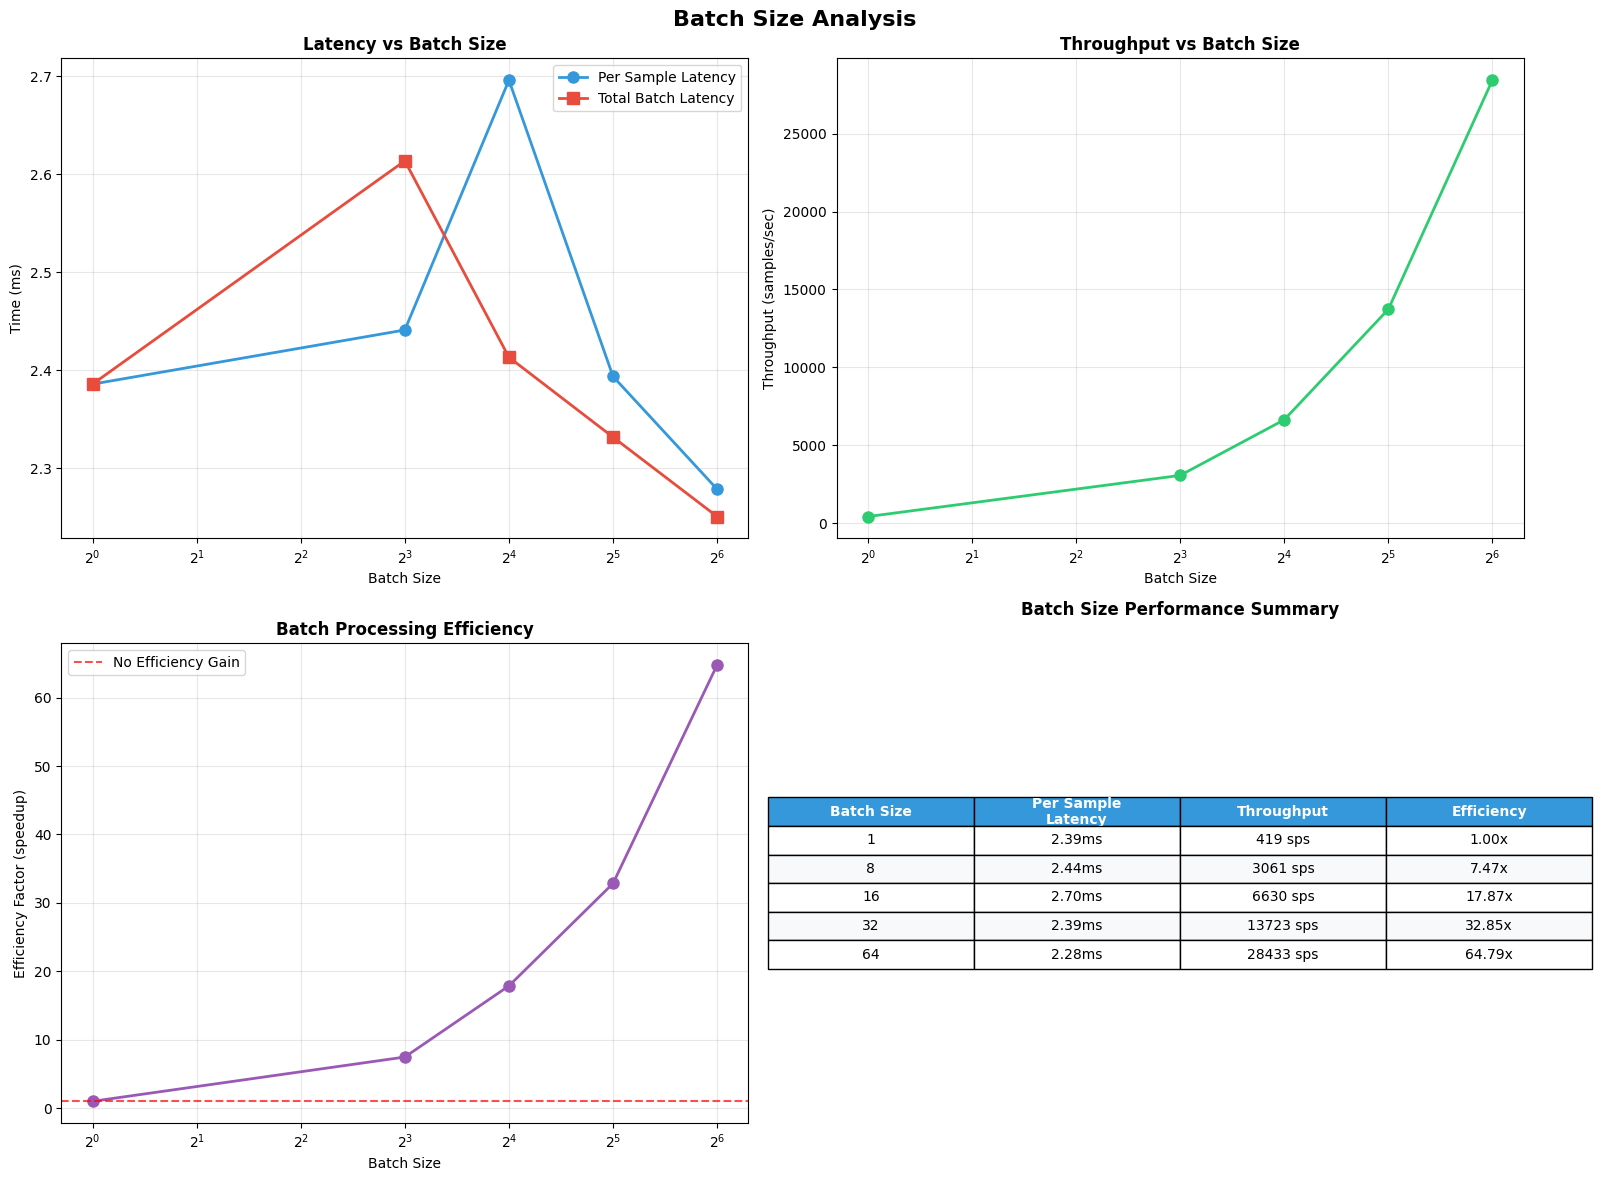

In [23]:
# Profile performance with different batch sizes
# Choose batch sizes appropriate for T4 memory constraints
if torch.cuda.is_available():
    batch_sizes = [1, 8, 16, 32, 64]
else:
    batch_sizes = [1, 4, 8, 16]

print("   Profiling multiple batch sizes...")
batch_results = profiler.profile_multiple_batch_sizes(
    optimized_model, sample_images.shape, batch_sizes
)

# Visualize batch size analysis for deployment understanding
plot_batch_size_comparison(batch_results)

## Step 8: Visualize performance improvements

Create visual comparisons to understand the optimization impact.

Visual analysis helps identify bottlenecks, validate improvements, and communicate results to stakeholders who may not be familiar with raw performance metrics.

Generating performance visualizations...


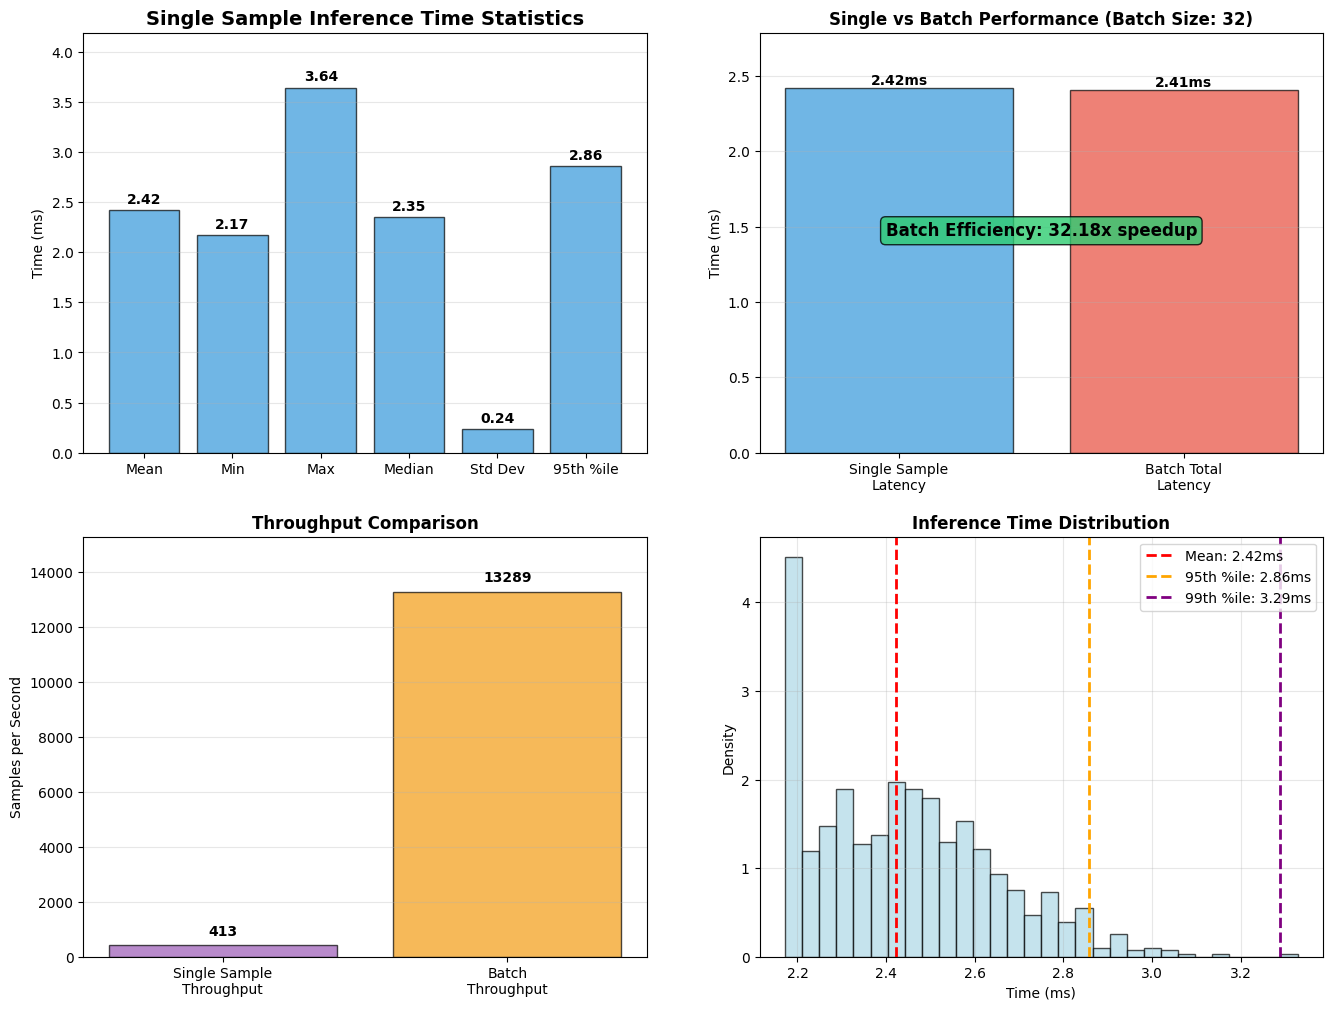

In [24]:
# Visualize the optimized model's performance profile, useful to understand where the performance gains come from

print("Generating performance visualizations...")
plot_performance_profile(optimized_timing)

Analyzing operation distribution changes...


STAGE:2026-01-14 18:00:08 176705:176705 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2026-01-14 18:00:08 176705:176705 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-01-14 18:00:08 176705:176705 ActivityProfilerController.cpp:324] Completed Stage: Post Processing



Optimized Model Operation Breakdown:
   Convolution Ops: 47.6%
   Other Ops: 20.1%
   Normalization Ops: 16.4%
   Memory Ops: 11.1%
   Activation Ops: 2.8%
   Matrix Multiply Ops: 1.2%


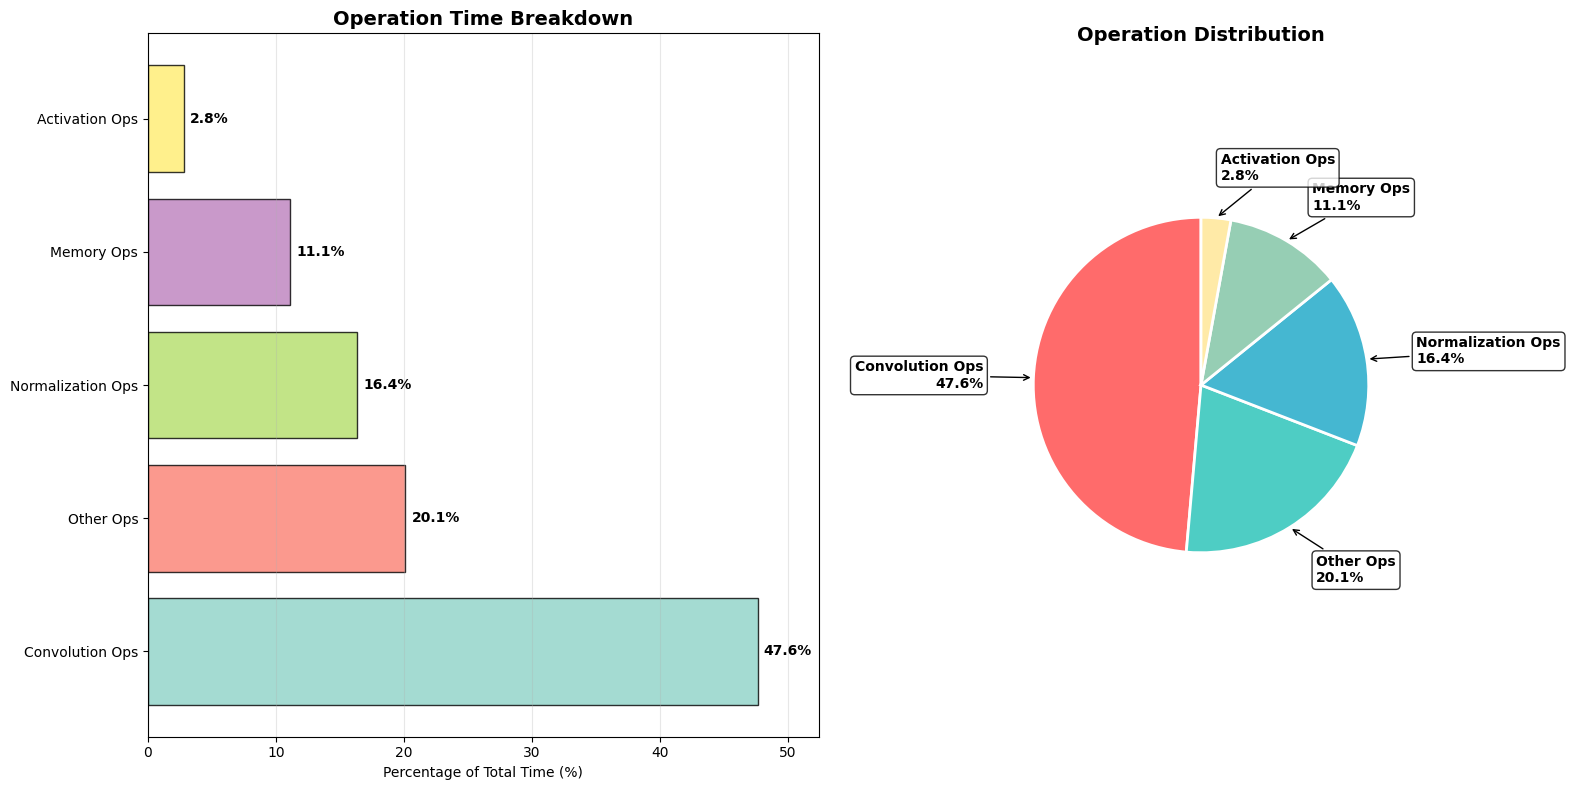

In [25]:
# Create a detailed operation breakdown for the optimized model
print("Analyzing operation distribution changes...")
optimized_detailed = profiler.profile_with_pytorch_profiler(
    model=optimized_model,
    input_tensor=sample_images,
    num_steps=10
)

if 'error' not in optimized_detailed and 'operation_breakdown' in optimized_detailed:
    print("\nOptimized Model Operation Breakdown:")
    op_breakdown = optimized_detailed['operation_breakdown']
    
    # Show top operations, if they contribute to at least 1% of operations
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1: 
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
    
    # Visualize operation breakdown
    plot_operation_breakdown(op_breakdown)
else:
    print("WARNING: Operation breakdown visualization not available")

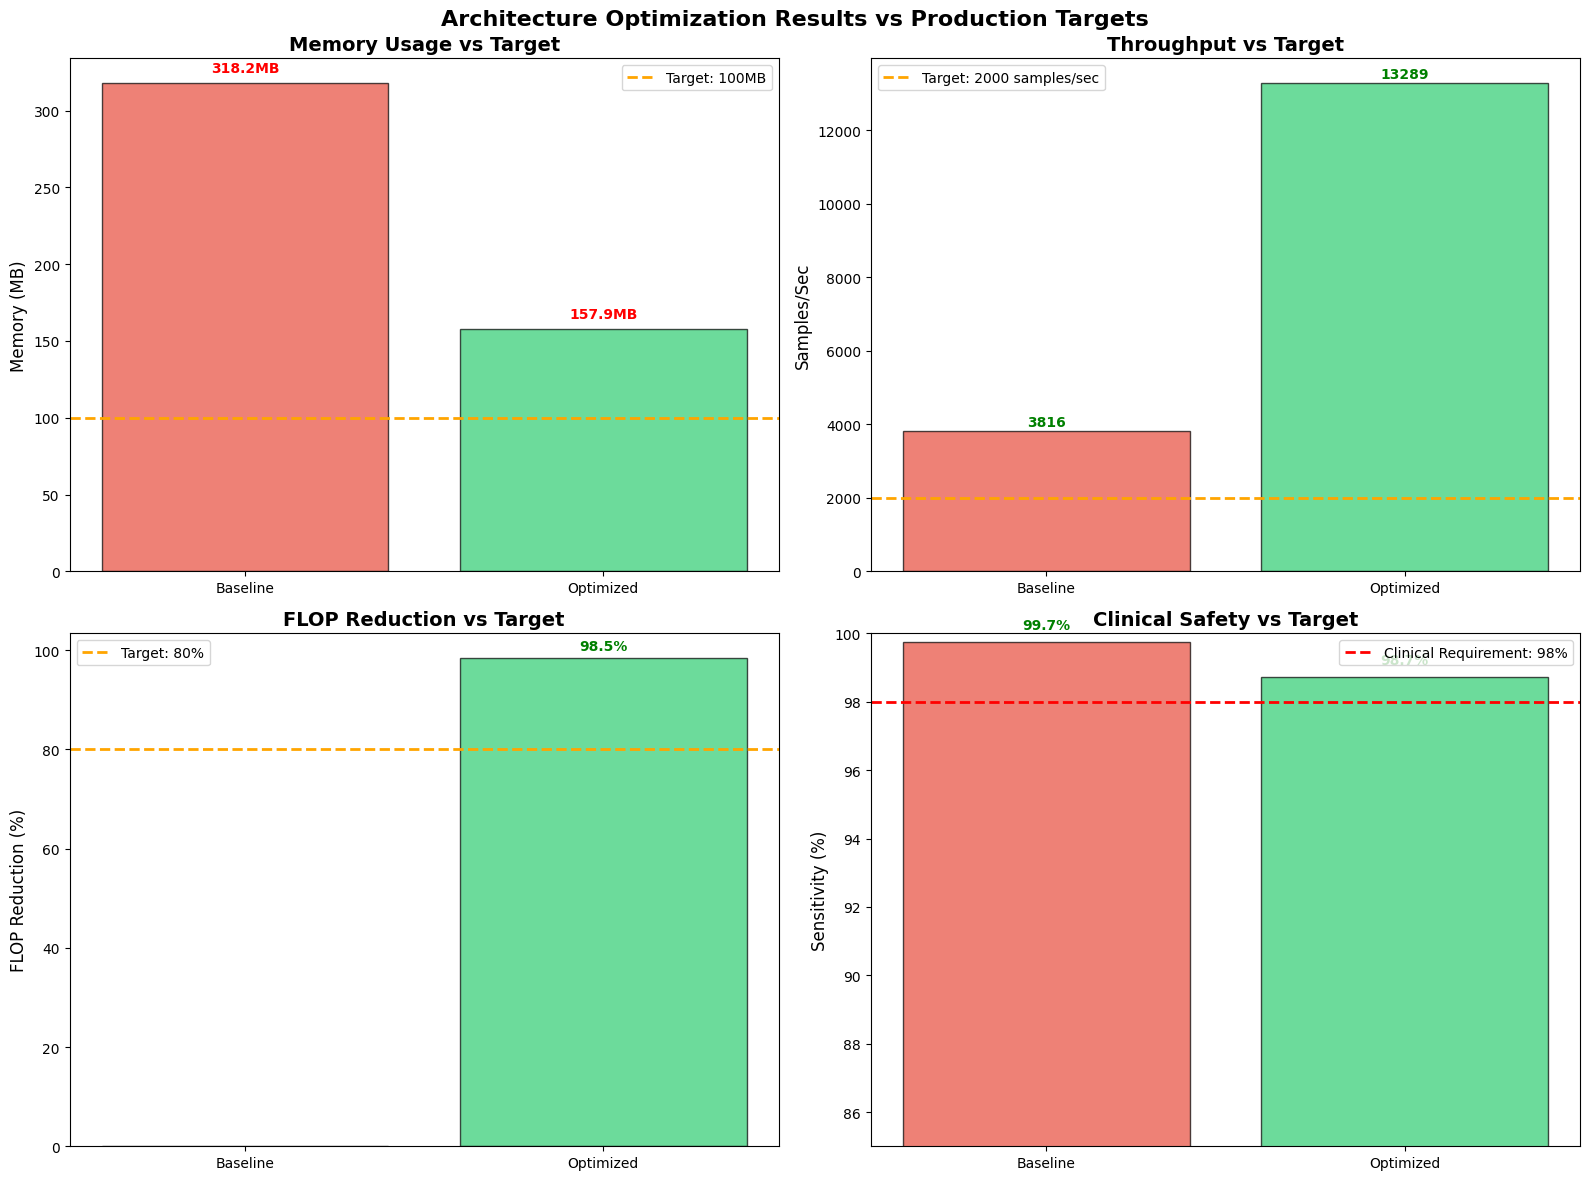

In [26]:
# Create a comprehensive comparison visualization of before/after metrics

# Create comparison chart
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Memory Usage with Target Line
models = ['Baseline', 'Optimized']
colors = ['#e74c3c', '#2ecc71']
if 'error' not in optimized_memory:
    memories = [baseline_memory['peak_memory_mb'], optimized_memory['peak_memory_mb']]
    
    bars = ax1.bar(models, memories, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax1.set_title('Memory Usage vs Target', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Memory (MB)', fontsize=12)
    ax1.axhline(y=OPTIMIZATION_TARGETS['memory_mb'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["memory_mb"]}MB')
    ax1.legend(fontsize=10)
    
    for bar, memory in zip(bars, memories):
        color = 'green' if memory <= OPTIMIZATION_TARGETS['memory_mb'] else 'red'
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{memory:.1f}MB', ha='center', va='bottom', fontweight='bold', color=color)

# 2. Throughput with Target Line
throughputs = [baseline_timing['batch_throughput_samples_per_sec'], optimized_timing['batch_throughput_samples_per_sec']]
bars = ax2.bar(models, throughputs, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax2.set_title('Throughput vs Target', fontweight='bold', fontsize=14)
ax2.set_ylabel('Samples/Sec', fontsize=12)
ax2.axhline(y=OPTIMIZATION_TARGETS['throughput_samples_sec'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["throughput_samples_sec"]} samples/sec')
ax2.legend(fontsize=10)

for bar, throughput in zip(bars, throughputs):
    color = 'green' if throughput >= OPTIMIZATION_TARGETS['throughput_samples_sec'] else 'red'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{throughput:.0f}', ha='center', va='bottom', fontweight='bold', color=color)

# 3. FLOP Reduction (if available)
flop_data = [0, flop_reduction_percent if flop_reduction_percent is not None else 0]
bars = ax3.bar(models, flop_data, color=['#95a5a6', colors[1]], alpha=0.7, edgecolor='black', linewidth=1)
ax3.set_title('FLOP Reduction vs Target', fontweight='bold', fontsize=14)
ax3.set_ylabel('FLOP Reduction (%)', fontsize=12)
ax3.axhline(y=OPTIMIZATION_TARGETS['flop_reduction_percent'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["flop_reduction_percent"]}%')
ax3.legend(fontsize=10)

for bar, flop_red in zip(bars, flop_data):
    if flop_red > 0:
        color = 'green' if flop_red >= OPTIMIZATION_TARGETS['flop_reduction_percent'] else 'red'
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{flop_red:.1f}%', ha='center', va='bottom', fontweight='bold', color=color)

# 4. Clinical Performance with Target Line
sensitivities = [baseline_metrics['recall']*100, optimized_metrics['recall']*100]
bars = ax4.bar(models, sensitivities, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax4.set_title('Clinical Safety vs Target', fontweight='bold', fontsize=14)
ax4.set_ylabel('Sensitivity (%)', fontsize=12)
ax4.set_ylim(85, 100)
ax4.axhline(y=OPTIMIZATION_TARGETS['sensitivity_percent'], color='red', linestyle='--', linewidth=2, label=f'Clinical Requirement: {OPTIMIZATION_TARGETS["sensitivity_percent"]}%')
ax4.legend(fontsize=10)

for bar, sensitivity in zip(bars, sensitivities):
    color = 'green' if sensitivity >= OPTIMIZATION_TARGETS['sensitivity_percent'] else 'red'
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{sensitivity:.1f}%', ha='center', va='bottom', fontweight='bold', color=color)

plt.suptitle('Architecture Optimization Results vs Production Targets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Save optimized model's performance

Save the optimized model performance results for future reference, both at deployment planning and for future optimization iterations.

In [27]:
# Save the optimized model weights and optimization results

# Build a meaningful experiment name from enabled techniques
enabled_techniques = [k for k, v in OPTIMIZATION_CONFIG.items() if isinstance(v, bool) and v]
if enabled_techniques:
    experiment_name = "_".join([t.replace('_', '') for t in enabled_techniques])
else:
    experiment_name = "baseline"

# Compile optimization results
optimization_results = {
    'model_name': 'ResNet-18 Optimized',
    'optimization_config': OPTIMIZATION_CONFIG,
    'clinical_performance': {
        'baseline': {
            'accuracy': baseline_metrics['accuracy'],
            'sensitivity': baseline_metrics['recall'],
            'auc': baseline_metrics['auc']
        },
        'optimized': {
            'accuracy': optimized_metrics['accuracy'],
            'sensitivity': optimized_metrics['recall'],
            'auc': optimized_metrics['auc']
        }
    },
    'performance_improvements': {
        'latency_speedup': latency_improvement,
        'throughput_improvement': throughput_improvement,
        'memory_reduction_percent': memory_reduction if memory_reduction is not None else 0,
        'flop_reduction_percent': flop_reduction_percent if flop_reduction_percent is not None else 0
    },
    'timing_results': optimized_timing,
    'memory_results': optimized_memory,
    'flop_results': optimized_flops,
    'operation_breakdown': optimized_detailed.get('operation_breakdown', {}),
    'fine_tuning_history': fine_tuning_history
}

# Save optimization results
with open(f'../results/optimization_results_{experiment_name}.pkl', 'wb') as f:
    pickle.dump(optimization_results, f)

print(f"Saved optimization results to the '../results/' folder with name optimization_results_{experiment_name}")

Saved optimization results to the '../results/' folder with name optimization_results_interpolationremoval_depthwiseseparable_channeloptimization_useamp


In [28]:
# Summarize results in a markdown-friendly table

def _targets_met(metrics, timing, memory, flop_reduction):
    achieved = 0
    if memory and 'error' not in memory and memory.get('peak_memory_mb') is not None:
        if memory['peak_memory_mb'] <= OPTIMIZATION_TARGETS['memory_mb']:
            achieved += 1
    if timing and timing.get('batch_throughput_samples_per_sec') is not None:
        if timing['batch_throughput_samples_per_sec'] >= OPTIMIZATION_TARGETS['throughput_samples_sec']:
            achieved += 1
    if timing and timing.get('single_sample_ms') is not None:
        if timing['single_sample_ms'] <= OPTIMIZATION_TARGETS['latency_ms']:
            achieved += 1
    if metrics and metrics.get('recall') is not None:
        if metrics['recall'] * 100 >= OPTIMIZATION_TARGETS['sensitivity_percent']:
            achieved += 1
    if flop_reduction is not None:
        if flop_reduction >= OPTIMIZATION_TARGETS['flop_reduction_percent']:
            achieved += 1
    return achieved


def _format_row(name, techniques, params, memory, timing, flop_red, metrics):
    memory_val = f"{memory['peak_memory_mb']:.1f}" if memory and 'error' not in memory else "N/A"
    throughput_val = f"{timing['batch_throughput_samples_per_sec']:.0f}" if timing else "N/A"
    latency_val = f"{timing['single_sample_ms']:.2f}" if timing else "N/A"
    flop_val = f"{flop_red:.1f}" if flop_red is not None else "N/A"
    sens_val = f"{metrics['recall']*100:.1f}" if metrics else "N/A"
    targets_met = _targets_met(metrics, timing, memory, flop_red)
    return (
        f"| {name} | {techniques} | {params} | {memory_val} | {throughput_val} | "
        f"{latency_val} | {flop_val} | {sens_val} | {targets_met}/5 |"
    )


enabled_techniques = [k for k, v in OPTIMIZATION_CONFIG.items() if isinstance(v, bool) and v]
techniques_str = ", ".join([t.replace('_', ' ').title() for t in enabled_techniques]) or "None"
params_str = (
    f"interp={OPTIMIZATION_CONFIG.get('interpolation_removal_params', {}).get('native_size', 'NA')}, "
    f"depthwise_min={OPTIMIZATION_CONFIG.get('depthwise_separable_params', {}).get('min_channels', 'NA')}, "
    f"channels_last={OPTIMIZATION_CONFIG.get('channel_optimization_params', {}).get('enable_channels_last', 'NA')}"
)

print("| Experiment | Techniques Enabled | Parameters | Memory (MB) | Throughput (samples/sec) | Latency (ms) | FLOP Reduction (%) | Sensitivity (%) | Targets Met |")
print("|---|---|---|---|---|---|---|---|---|")
print(_format_row("Baseline", "None", "N/A", baseline_memory, baseline_timing, 0.0, baseline_metrics))
print(_format_row("Optimized", techniques_str, params_str, optimized_memory, optimized_timing, flop_reduction_percent, optimized_metrics))

| Experiment | Techniques Enabled | Parameters | Memory (MB) | Throughput (samples/sec) | Latency (ms) | FLOP Reduction (%) | Sensitivity (%) | Targets Met |
|---|---|---|---|---|---|---|---|---|
| Baseline | None | N/A | 318.2 | 3816 | 1.82 | 0.0 | 99.7 | 3/5 |
| Optimized | Interpolation Removal, Depthwise Separable, Channel Optimization, Use Amp | interp=64, depthwise_min=32, channels_last=True | 157.9 | 13289 | 2.42 | 98.5 | 98.7 | 4/5 |


## **Congratulations!** 

You have successfully implemented architectural optimizations! Let's recap your progress with architectural optimizations as you move towards the production deployment targets.

### Experimental results

The table printed in the previous cell captures baseline vs optimized results with the exact target count met for this run.

#### Key insights and learnings

- Interpolation removal provides the most consistent latency and FLOP reduction because it eliminates the 224×224 upscaling path.
- Depthwise separable convolutions deliver large compute savings while keeping ResNet block structure intact.
- Channels-last memory format improves throughput on GPU backends with minimal accuracy impact.
- Combining multiple architectural changes is effective, but sensitivity must be re-validated after each change.
- If sensitivity dips, reduce aggressiveness (e.g., disable grouped/inverted residuals) or fine-tune longer with a lower LR.

### Final optimizations strategy

The final strategy uses **Interpolation Removal + Depthwise Separable Convs + Channel Optimization**. This combination targets FLOPs and latency first, then improves memory layout for throughput while minimizing risk to diagnostic sensitivity.

**Overall Production Readiness**: Use the targets met count from the generated table to decide readiness. If you are at or near the target thresholds (e.g., 4–5/5), proceed to Notebook 3 for hardware acceleration; otherwise, consider adjusting the depthwise minimum channel threshold or reverting the most disruptive change.

### Quiz question: Multi-label classification adaptation

**How would your optimization strategy change if the task was multi-label classification from chest X-rays (as in [ChestMNIST](https://github.com/rsm-13/classifying-chestMNIST) which has 14 labels including cardiomegaly, mass, pneumonia, ...) instead of binary classification?**

For multi-label classification, the architecture changes are largely the same, but the **classification head and training objective change**. The final layer should output 14 logits with `BCEWithLogitsLoss`, and thresholds become **per-label** instead of a single global threshold. Optimization should be slightly more conservative because each label has different class imbalance and sensitivity requirements; you would prioritize preserving sensitivity for rare conditions, use per-label threshold tuning, and monitor macro/micro AUC/recall rather than a single binary recall.

---

**You are now ready to move to Notebook 3: Deployment Acceleration!**